In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
import scipy.stats
import os
from adjustText import adjust_text
import matplotlib.patheffects as PathEffects
import warnings
warnings.filterwarnings('ignore')
plt.rc('font', family='Helvetica')

In [2]:
KLIFS = pd.read_csv('../../source_data/16_KLIFS/KLIFS_compiled.csv')
#KLIFS = KLIFS[KLIFS['KLIFS_idx']!='linker:50'].reset_index(drop=True)
library = pd.read_csv('../../source_data/02_library/CDK_library_final.csv')

SAV_ABE1 = pd.read_csv('../../screening_data/04_editing/SAVs/ABE_subpool1.zip')
SAV_ABE1 = pd.merge(SAV_ABE1, library[['gRNA_id', 'Gene']], on='gRNA_id')

SAV_CBE1 = pd.read_csv('../../screening_data/04_editing/SAVs/CBE_subpool1.zip')
SAV_CBE1 = pd.merge(SAV_CBE1, library[['gRNA_id', 'Gene']], on='gRNA_id')


SAV_ABE2 = pd.read_csv('../../screening_data/04_editing/SAVs/ABE_subpool2.zip')
SAV_ABE2 = pd.merge(SAV_ABE2, library[['gRNA_id', 'Gene']], on='gRNA_id')

SAV_CBE2 = pd.read_csv('../../screening_data/04_editing/SAVs/CBE_subpool2.zip')
SAV_CBE2 = pd.merge(SAV_CBE2, library[['gRNA_id', 'Gene']], on='gRNA_id')

In [3]:
def rg_dict_gen(SAV_ABE2, SAV_CBE2, genes, min_edit):

    #first CBE
    rg_CBE = []
    for gene in genes:
        pocket = list(KLIFS[gene])

        relevant_guides = []
        for residue in pocket:
            subset = SAV_CBE2[(SAV_CBE2['Gene']==gene) & (SAV_CBE2['Codon']==residue) & (SAV_CBE2['%Reads']>=min_edit)]
            relevant_guides.append(list(subset['gRNA_id']))
        
        rg_CBE.append(relevant_guides)

    #then ABE
    rg_ABE = []
    for gene in genes:
        pocket = list(KLIFS[gene])

        relevant_guides = []
        for residue in pocket:
            subset = SAV_ABE2[(SAV_ABE2['Gene']==gene) & (SAV_ABE2['Codon']==residue) & (SAV_ABE2['%Reads']>=min_edit)]
            relevant_guides.append(list(subset['gRNA_id']))
        
        rg_ABE.append(relevant_guides)

    CBE_rg_dict = dict(zip(genes, rg_CBE))
    ABE_rg_dict = dict(zip(genes, rg_ABE))

    return CBE_rg_dict, ABE_rg_dict

from matplotlib.patches import Rectangle

def finger_plotv3(ABE_s2, CBE_s2, ABE_rg_dict, CBE_rg_dict, genes, FDR_cutoff, condition):

    #add coloring depending on if LFC >0 or LFC<0

    KLIFS2 = KLIFS.copy()

    #genes = ['CDK12', 'CDK13']

    for gene in genes:
        c = CBE_rg_dict[gene]
        a = ABE_rg_dict[gene]

        for i, val in KLIFS2.iterrows():
            nn = val[gene]
            try:
                subset_ABE = list(ABE_s2[ABE_s2['gRNA_id'].isin(a[i])][f'LFC_median_ABE_{condition}'])
                subset_CBE = list(CBE_s2[CBE_s2['gRNA_id'].isin(c[i])][f'LFC_median_CBE_{condition}'])

                #num_sig_ABE = len(ABE_s2[(ABE_s2['gRNA_id'].isin(a[i])) & (ABE_s2[f'FDR_ABE_{condition}']<FDR_cutoff)])
                #num_sig_CBE = len(CBE_s2[(CBE_s2['gRNA_id'].isin(c[i])) & (CBE_s2[f'FDR_CBE_{condition}']<FDR_cutoff)])

                num_sig_ABE_up = len(ABE_s2[(ABE_s2['gRNA_id'].isin(a[i])) & (ABE_s2[f'FDR_ABE_{condition}']<FDR_cutoff) & (ABE_s2[f'LFC_median_ABE_{condition}']>0)])
                num_sig_CBE_up = len(CBE_s2[(CBE_s2['gRNA_id'].isin(c[i])) & (CBE_s2[f'FDR_CBE_{condition}']<FDR_cutoff) & (CBE_s2[f'LFC_median_CBE_{condition}']>0)])
                num_sig_ABE_down = len(ABE_s2[(ABE_s2['gRNA_id'].isin(a[i])) & (ABE_s2[f'FDR_ABE_{condition}']<FDR_cutoff)& (ABE_s2[f'LFC_median_ABE_{condition}']<0)])
                num_sig_CBE_down = len(CBE_s2[(CBE_s2['gRNA_id'].isin(c[i])) & (CBE_s2[f'FDR_CBE_{condition}']<FDR_cutoff) & (CBE_s2[f'LFC_median_CBE_{condition}']<0)])
        
            except:
                subset_ABE = list(ABE_s2[ABE_s2['gRNA_id'].isin(a[i])][f'LFC_median_{condition}'])
                subset_CBE = list(CBE_s2[CBE_s2['gRNA_id'].isin(c[i])][f'LFC_median_{condition}'])

                num_sig_ABE_up = len(ABE_s2[(ABE_s2['gRNA_id'].isin(a[i])) & (ABE_s2[f'FDR_{condition}']<FDR_cutoff) & (ABE_s2[f'LFC_median_{condition}']>0)])
                num_sig_CBE_up = len(CBE_s2[(CBE_s2['gRNA_id'].isin(c[i])) & (CBE_s2[f'FDR_{condition}']<FDR_cutoff) & (CBE_s2[f'LFC_median_{condition}']>0)])
                num_sig_ABE_down = len(ABE_s2[(ABE_s2['gRNA_id'].isin(a[i])) & (ABE_s2[f'FDR_{condition}']<FDR_cutoff)& (ABE_s2[f'LFC_median_{condition}']<0)])
                num_sig_CBE_down = len(CBE_s2[(CBE_s2['gRNA_id'].isin(c[i])) & (CBE_s2[f'FDR_{condition}']<FDR_cutoff) & (CBE_s2[f'LFC_median_{condition}']<0)])


            total_sig_up = num_sig_ABE_up + num_sig_CBE_up
            total_sig_down = num_sig_ABE_down + num_sig_CBE_down
            comb1 = subset_ABE + subset_CBE

            KLIFS2.loc[KLIFS2[gene]==nn, f'{gene}_guides'] = len(comb1)
            KLIFS2.loc[KLIFS2[gene]==nn, f'{gene}_avg'] = np.average(comb1)
            KLIFS2.loc[KLIFS2[gene]==nn, f'{gene}_num_sig_up'] = total_sig_up
            KLIFS2.loc[KLIFS2[gene]==nn, f'{gene}_num_sig_down'] = total_sig_down
    
    #k2 = KLIFS2[['CDK12_guides', 'CDK12_avg', 'CDK13_guides', 'CDK13_avg']]

    for gene in genes:
        KLIFS2[gene] = KLIFS2[f'{gene}_avg']/KLIFS2[f'{gene}_guides']

    plotting2 = KLIFS2[genes].T

    fig, ax = plt.subplots(figsize=(20,1.5))
    sns.heatmap(plotting2, cmap='seismic', center=0, ax=ax, linewidth=0.5)
    ax.set_facecolor('lightgrey')

    for idx1, gene in enumerate(genes):
        sig_up = list(KLIFS2[f'{gene}_num_sig_up']>0)
        sig_down = list(KLIFS2[f'{gene}_num_sig_down']>0)

        for idx, i in enumerate(sig_up):
            if i==True:
                if sig_down[idx]==True:
                    ax.add_patch(Rectangle((idx,idx1), 1, 1, ec='purple', fc='none', lw=1, hatch='///'))
                elif sig_down[idx]==False:
                    ax.add_patch(Rectangle((idx,idx1), 1, 1, ec='red', fc='none', lw=1, hatch='///'))

            elif i==False:
                if sig_down[idx]==True:
                    ax.add_patch(Rectangle((idx,idx1), 1, 1, ec='blue', fc='none', lw=1, hatch='///'))



    ax.set_title(f'{condition}', fontsize=12)

    return plotting2

In [4]:
ABE_s1_plasmid = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/Plasmid_base/ABE_subpool1_barcode_Plasmid_base.csv')
CBE_s1_plasmid = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/Plasmid_base/CBE_subpool1_barcode_Plasmid_base.csv')

ABE_s2_plasmid = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/Plasmid_base/CDK12_13_ABE_barcode_Plasmid_base.csv')
CBE_s2_plasmid = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/Plasmid_base/CDK12_13_CBE_barcode_Plasmid_base.csv')

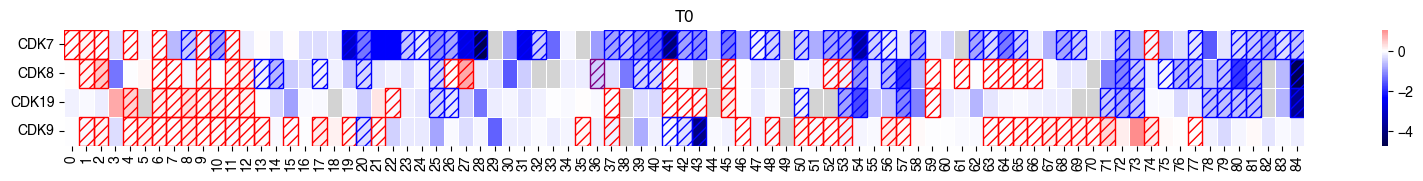

In [5]:
min_base_counts = 100
FDR_cutoff = 0.1
ABE_s1 = ABE_s1_plasmid[ABE_s1_plasmid['base_RAW']>=min_base_counts]
CBE_s1 = CBE_s1_plasmid[CBE_s1_plasmid['base_RAW']>=min_base_counts]

genes = ['CDK7', 'CDK8', 'CDK19', 'CDK9']
min_edit = 20

CBE_rg_dict, ABE_rg_dict = rg_dict_gen(SAV_ABE1, SAV_CBE1, genes, min_edit)

condition = 'T0'
plotting_a = finger_plotv3(ABE_s1, CBE_s1, ABE_rg_dict, CBE_rg_dict, genes, FDR_cutoff, condition)

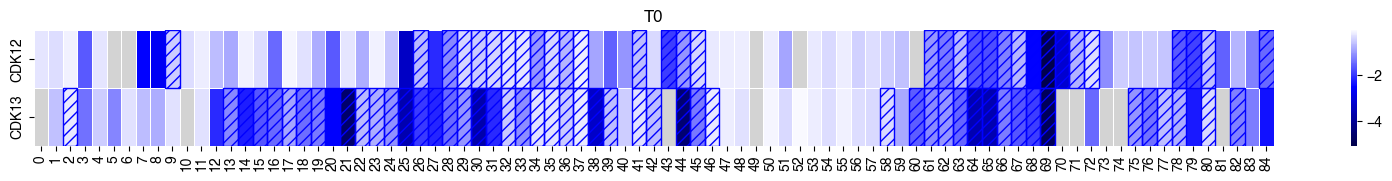

In [6]:
min_base_counts = 100
FDR_cutoff = 0.1
ABE_s2 = ABE_s2_plasmid[ABE_s2_plasmid['base_RAW']>=min_base_counts]
CBE_s2 = CBE_s2_plasmid[CBE_s2_plasmid['base_RAW']>=min_base_counts]

genes = ['CDK12', 'CDK13']
min_edit = 20

CBE_rg_dict, ABE_rg_dict = rg_dict_gen(SAV_ABE2, SAV_CBE2, genes, min_edit)

condition = 'T0'
plotting_a = finger_plotv3(ABE_s2, CBE_s2, ABE_rg_dict, CBE_rg_dict, genes, FDR_cutoff, condition)

In [7]:
ABE_s1 = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/DMSO_base/ABE_subpool1_barcode_DMSO_base.csv')
CBE_s1 = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/DMSO_base/CBE_subpool1_barcode_DMSO_base.csv')

ABE_s2 = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/DMSO_base/CDK12_13_ABE_barcode_DMSO_base.csv')
CBE_s2 = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/DMSO_base/CDK12_13_CBE_barcode_DMSO_base.csv')

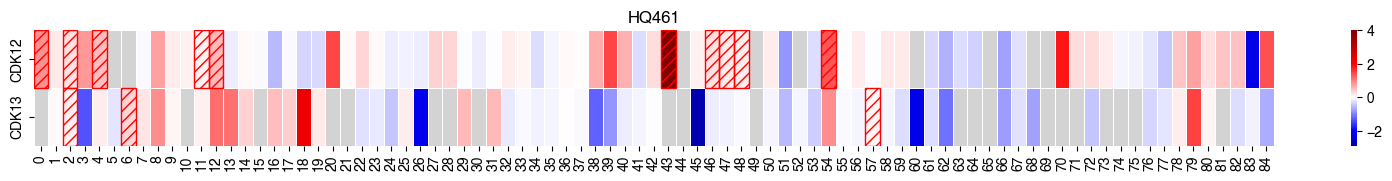

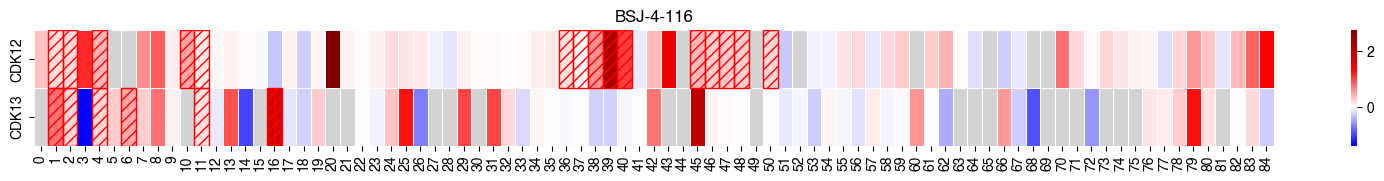

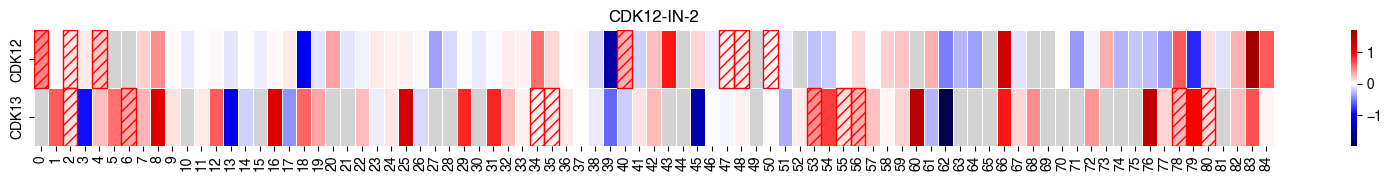

In [8]:
min_base_counts = 100
FDR_cutoff = 0.1
ABE_s2 = ABE_s2[ABE_s2['base_RAW']>=min_base_counts]
CBE_s2 = CBE_s2[CBE_s2['base_RAW']>=min_base_counts]

genes = ['CDK12', 'CDK13']
min_edit = 20

CBE_rg_dict, ABE_rg_dict = rg_dict_gen(SAV_ABE2, SAV_CBE2, genes, min_edit)

condition = 'HQ461'
plotting_b = finger_plotv3(ABE_s2, CBE_s2, ABE_rg_dict, CBE_rg_dict, genes, FDR_cutoff, condition)

condition = 'BSJ-4-116'
plotting_c = finger_plotv3(ABE_s2, CBE_s2, ABE_rg_dict, CBE_rg_dict, genes, FDR_cutoff, condition)

condition = 'CDK12-IN-2'
plotting_d = finger_plotv3(ABE_s2, CBE_s2, ABE_rg_dict, CBE_rg_dict, genes, FDR_cutoff, condition)

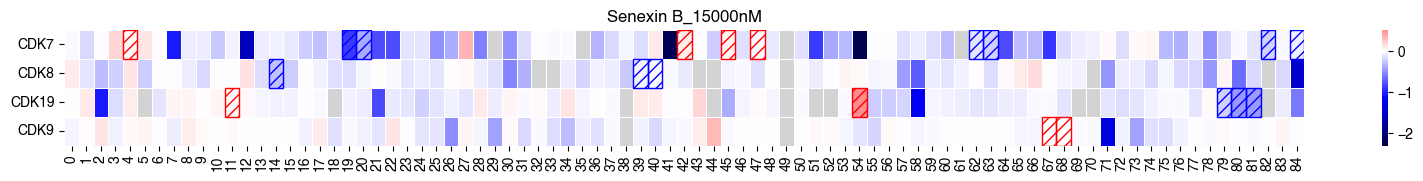

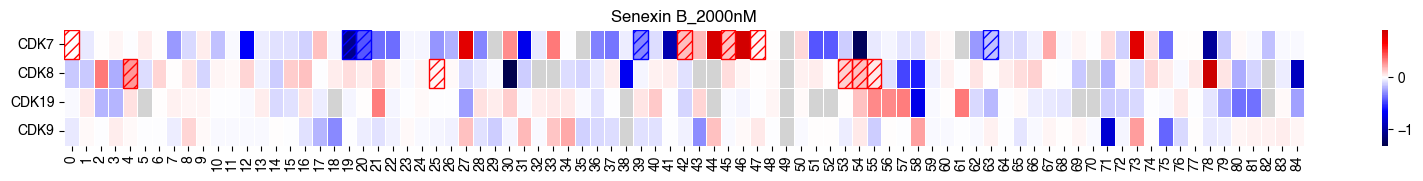

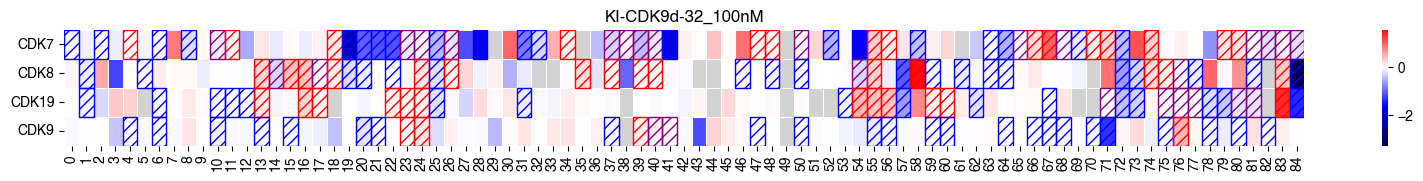

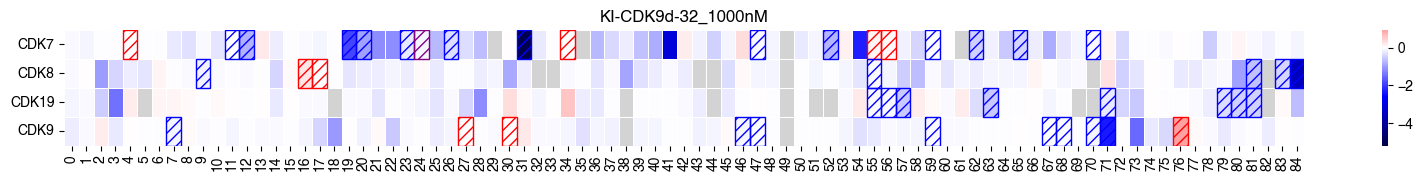

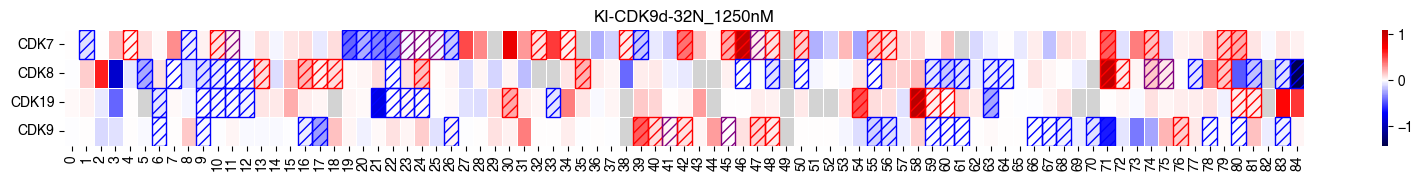

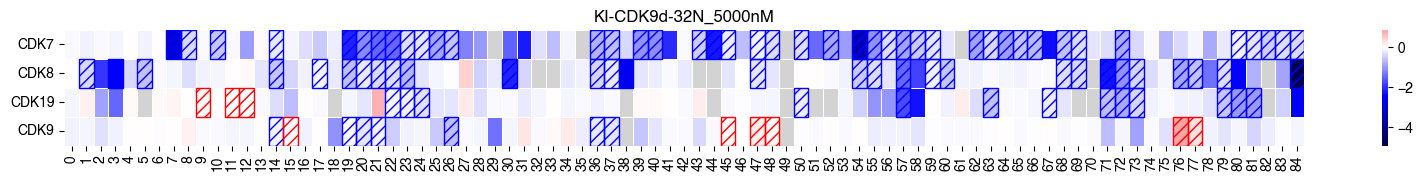

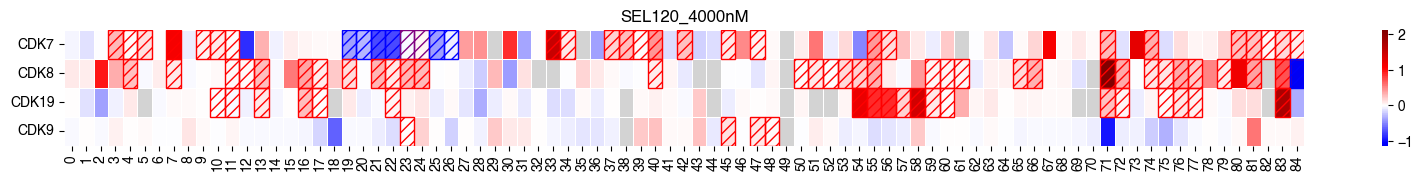

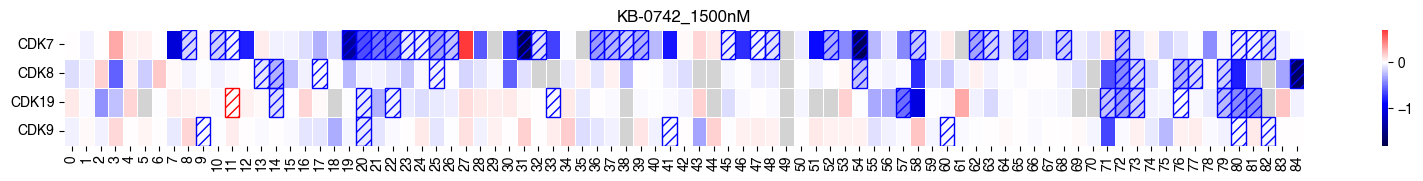

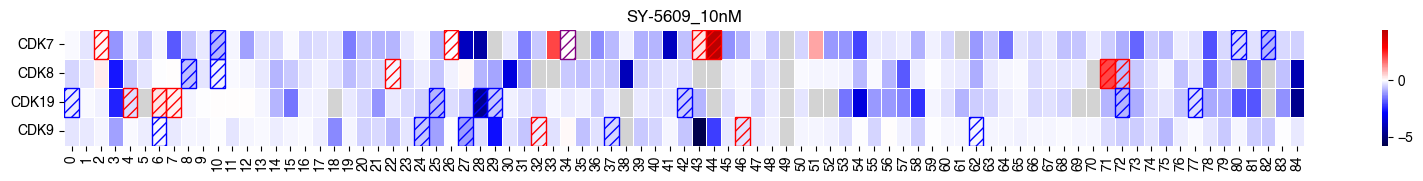

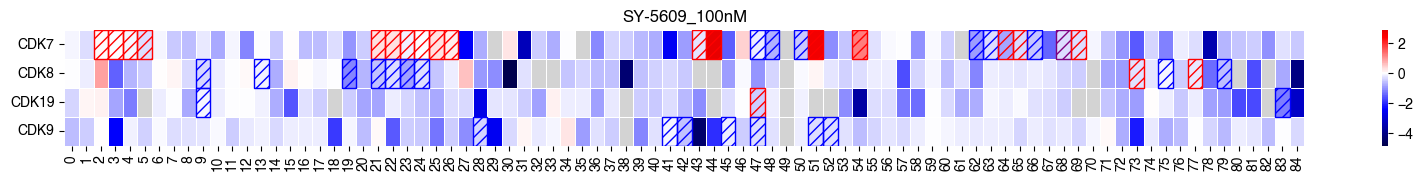

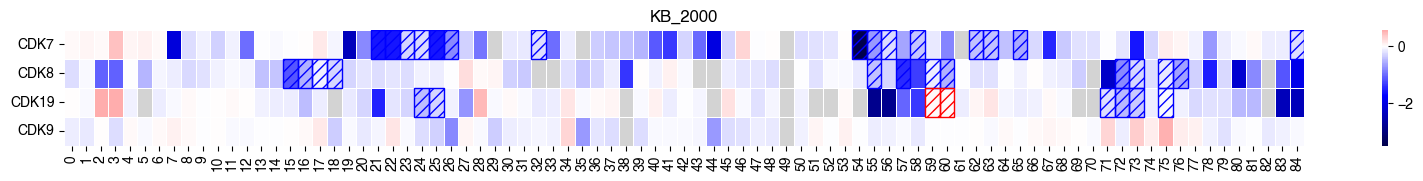

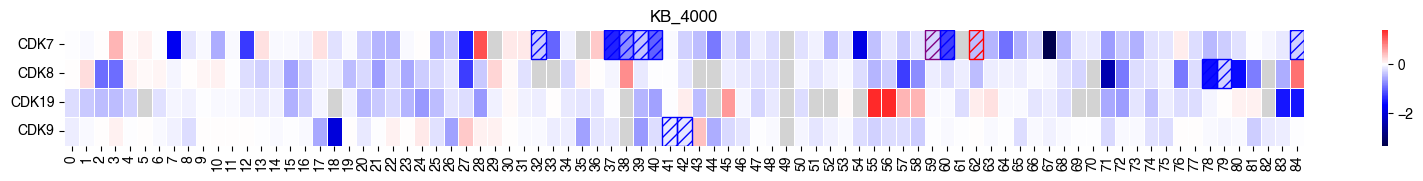

In [17]:
min_base_counts = 100
FDR_cutoff = 0.1
ABE_s1 = ABE_s1[ABE_s1['base_RAW']>=min_base_counts]
CBE_s1 = CBE_s1[CBE_s1['base_RAW']>=min_base_counts]

genes = ['CDK7', 'CDK8', 'CDK19', 'CDK9']

CBE_rg_dict, ABE_rg_dict = rg_dict_gen(SAV_ABE1, SAV_CBE1, genes, min_edit)


condition = 'Senexin B_15000nM'
plotting_a = finger_plotv3(ABE_s1, CBE_s1, ABE_rg_dict, CBE_rg_dict, genes, FDR_cutoff, condition)

condition = 'Senexin B_2000nM'
plotting_b = finger_plotv3(ABE_s1, CBE_s1, ABE_rg_dict, CBE_rg_dict, genes, FDR_cutoff, condition)

condition = 'KI-CDK9d-32_100nM'
plotting_c = finger_plotv3(ABE_s1, CBE_s1, ABE_rg_dict, CBE_rg_dict, genes, FDR_cutoff, condition)

condition = 'KI-CDK9d-32_1000nM'
plotting_d = finger_plotv3(ABE_s1, CBE_s1, ABE_rg_dict, CBE_rg_dict, genes, FDR_cutoff, condition)

condition = 'KI-CDK9d-32N_1250nM'
plotting_e = finger_plotv3(ABE_s1, CBE_s1, ABE_rg_dict, CBE_rg_dict, genes, FDR_cutoff, condition)

condition = 'KI-CDK9d-32N_5000nM'
plotting_f = finger_plotv3(ABE_s1, CBE_s1, ABE_rg_dict, CBE_rg_dict, genes, FDR_cutoff, condition)

condition = 'SEL120_4000nM'
plotting_g = finger_plotv3(ABE_s1, CBE_s1, ABE_rg_dict, CBE_rg_dict, genes, FDR_cutoff, condition)

condition = 'KB-0742_1500nM'
plotting_gg = finger_plotv3(ABE_s1, CBE_s1, ABE_rg_dict, CBE_rg_dict, genes, FDR_cutoff, condition)

#--------SY-------
ABE_sy = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/DMSO_base/SY_5609_ABE_barcode_DMSO_base.csv')
CBE_sy = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/DMSO_base/SY_5609_CBE_barcode_DMSO_base.csv')
ABE_sy = ABE_sy[ABE_sy['base_RAW']>=min_base_counts]
CBE_sy = CBE_sy[CBE_sy['base_RAW']>=min_base_counts]

condition = 'SY-5609_10nM'
plotting_h = finger_plotv3(ABE_sy, CBE_sy, ABE_rg_dict, CBE_rg_dict, genes, FDR_cutoff, condition)

condition = 'SY-5609_100nM'
plotting_i = finger_plotv3(ABE_sy, CBE_sy, ABE_rg_dict, CBE_rg_dict, genes, FDR_cutoff, condition)

#----compoun mutants------
#Note: hacky solution here; should limit to CBE-editable locations
ABE_comp = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/DMSO_base/Compound_mutant_barcode_DMSO_base.csv')
CBE_comp = ABE_comp
ABE_comp = ABE_comp[ABE_comp['base_RAW']>=min_base_counts]
CBE_comp = CBE_comp[CBE_comp['base_RAW']>=min_base_counts]

condition = 'KB_2000'
plotting_j = finger_plotv3(ABE_comp, CBE_comp, ABE_rg_dict, CBE_rg_dict, genes, FDR_cutoff, condition)

condition = 'KB_4000'
plotting_k = finger_plotv3(ABE_comp, CBE_comp, ABE_rg_dict, CBE_rg_dict, genes, FDR_cutoff, condition)



In [15]:
ABE_comp['LFC_median_KB_2000']

0      -0.341793
1       0.722489
2       0.927201
3       0.229201
4      -0.581750
          ...   
2725   -0.723958
2726   -0.356491
2727    1.411030
2728   -0.653535
2729   -0.662367
Name: LFC_median_KB_2000, Length: 2715, dtype: float64